# Credit Scoring + PSI/CSI Monitoring + Champion-Challenger

A full credit-model lifecycle on a *Give Me Some Credit*-schema dataset (~150k loans):
**train** two models, frame the swap as a **champion-challenger** decision, then
**monitor** for post-deployment drift with PSI/CSI.

- **Champion** = Logistic Regression on WoE features (transparent scorecard, the incumbent).
- **Challenger** = LightGBM on raw features (stronger, less interpretable).

All maths that an interviewer will probe (WoE/IV, KS, PSI/CSI, the bootstrap decision)
is hand-rolled in `src/`. The notebook narrates; the modules do the work.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
from IPython.display import Image, display
from src.data_generator import TARGET, load_raw, assign_batches, apply_drift, drift_spec, PAST_DUE_COLS
from src.prep import prep_fit, prep_apply, feature_columns
from src.woe import fit_woe, iv_table, select_features
from src.train import train_champion, train_challenger, score_champion, score_challenger, cross_val_auc, champion_coefficients
from src.metrics import discrimination_summary, lift_table
from src.decision import bootstrap_recall_diff, decide, economic_impact
from src.psi import run_monitoring, drift_table, verify_drift
from src import plots
OUT = '../outputs'
raw = assign_batches(load_raw())
print('rows:', len(raw), '| base rate:', round(raw[TARGET].mean(), 4))

rows: 150000 | base rate: 0.0668


## 1. Data & quirks

Before modelling, interrogate the data rather than accepting `describe()` at face value
,  the exact skill the role screens for. This dataset hides four traps.

In [2]:
print('target imbalance     :', round(raw[TARGET].mean()*100, 2), '% default')
print('MonthlyIncome missing:', round(raw['MonthlyIncome'].isna().mean()*100, 2), '%')
print('Dependents missing   :', round(raw['NumberOfDependents'].isna().mean()*100, 2), '%')
print('RevolvingUtil max    :', round(raw['RevolvingUtilizationOfUnsecuredLines'].max(), 1), '(>1 is plausible, 50000 is not)')
print('age min              :', raw['age'].min(), '(a 0-year-old borrower?)')
for c in PAST_DUE_COLS:
    print(f'sentinel in {c[:22]:22} -> #96={int((raw[c]==96).sum())} #98={int((raw[c]==98).sum())}')

target imbalance     : 6.68 % default
MonthlyIncome missing: 19.85 %
Dependents missing   : 2.66 %
RevolvingUtil max    : 50605.7 (>1 is plausible, 50000 is not)
age min              : 0.0 (a 0-year-old borrower?)
sentinel in NumberOfTime30-59DaysP -> #96=119 #98=68
sentinel in NumberOfTime60-89DaysP -> #96=78 #98=109
sentinel in NumberOfTimes90DaysLat -> #96=91 #98=96


**Insight.** The `96`/`98` values repeating across the past-due columns are not customers who were late 96 times, they are sentinel codes for 'not available'. Left raw, the model would learn a fake risk spike. We also see ~20% missing income (likely informative, not random), revolving-utilisation outliers in the tens of thousands, and an `age=0` typo. Each is handled deliberately in prep.

## 2. Data prep & feature engineering

Split by time batch (1-3 train, 4-6 test), **not** a random split, so we never train on the
future. Every statistic (medians, winsor caps) is learned on train only and replayed on test.

In [3]:
train_raw, test_raw = raw[raw.batch <= 3], raw[raw.batch >= 4]
params = prep_fit(train_raw)
train, test = prep_apply(train_raw, params), prep_apply(test_raw, params)
print('train/test:', train.shape, test.shape, '| residual NaNs:', int(train.isna().sum().sum()))
print('engineered:', [c for c in train.columns if c not in raw.columns])

train/test: (75000, 19) (75000, 19) | residual NaNs: 0
engineered: ['had_sentinel_pastdue', 'income_missing', 'dependents_missing', 'total_past_due', 'has_been_late', 'monthly_debt', 'income_per_dependent']


**Insight.** Zero residual missing, sentinels neutralised, four engineered ratios added (`total_past_due`, `has_been_late`, `monthly_debt`, `income_per_dependent`). Because the caps come from train, a drifted test value cannot leak back into the fitted parameters.

## 3. Weight of Evidence / Information Value

WoE replaces each value with `ln(%good/%bad)` of its bin (linearising the feature for the LR
champion); IV ranks predictive power. The rule: drop IV<0.02, **investigate IV>0.5** (usually
leakage, not a gift).

,feature,iv,strength
0,RevolvingUtilizationOfUnsecuredLines,0.8310,suspicious (>0.5 -> check leakage)
1,DebtRatio,0.4839,strong
2,monthly_debt,0.2494,medium
3,total_past_due,0.0837,weak
4,age,0.0687,weak
5,MonthlyIncome,0.0630,weak
6,has_been_late,0.0568,weak
7,NumberOfTime30-59DaysPastDueNotWorse,0.0486,weak


flagged IV>0.5: ['RevolvingUtilizationOfUnsecuredLines']


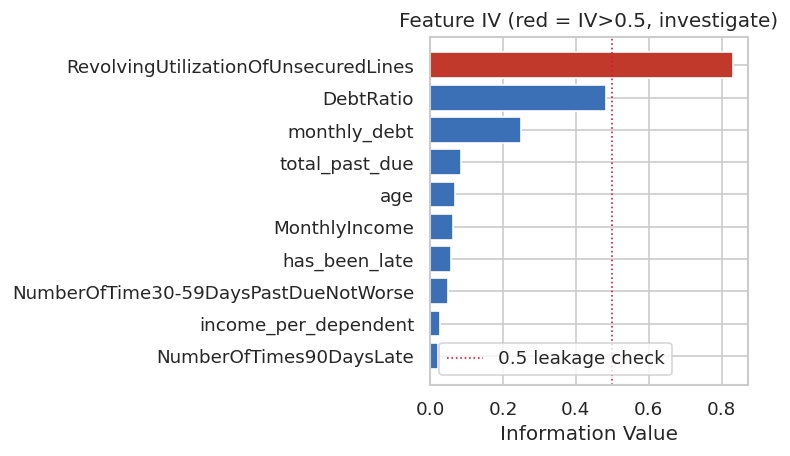

In [4]:
woe_model = fit_woe(train, feature_columns(train), TARGET)
ivt = iv_table(woe_model)
keep, flagged = select_features(woe_model)
feats = keep + flagged
display(ivt.head(8))
print('flagged IV>0.5:', flagged)
plots.plot_iv(ivt, f'{OUT}/iv_ranking.png'); Image(f'{OUT}/iv_ranking.png')

**Insight.** `RevolvingUtilizationOfUnsecuredLines` trips the IV>0.5 screen. Investigated, it is the canonical strongest credit feature (revolving utilisation), not target leakage, so it is **retained with a caveat** rather than blindly dropped. The screen firing and being resolved *is* the validation process working.

## 4. Models, champion (LR/WoE) vs challenger (LightGBM)

LR is the champion not because it is strongest but because the WoE scorecard is auditable.
The challenger must earn the swap. Coefficient signs are a sanity check: a riskier feature
should push the log-odds up.

In [5]:
champ = train_champion(train, feats, TARGET)
chall = train_challenger(train, feats, TARGET)
display(champion_coefficients(champ).head(6))
cv_mean, cv_std = cross_val_auc(train, feats, TARGET, 'champion')
print(f'champion 5-fold CV AUC: {cv_mean:.4f} +/- {cv_std:.4f} (WoE refit per fold)')

,feature,coef
0,MonthlyIncome,-1.760738
1,age,-1.123529
2,RevolvingUtilizationOfUnsecuredLines,-1.100257
3,total_past_due,-1.053217
4,monthly_debt,-0.834132
5,DebtRatio,-0.773132


champion 5-fold CV AUC: 0.8077 +/- 0.0097 (WoE refit per fold)


**Insight.** CV refits WoE inside every fold, so the champion's CV AUC never sees its own validation rows during binning, the leakage-free protocol. CV (~0.81) matches the held-out test below: no overfit.

## 5. Evaluation, AUC / KS / Gini / lift / calibration

On the clean held-out window. Accuracy is omitted on purpose: predicting 'all good' scores 93%
accuracy and catches zero defaulters.

,auc,ks,gini
champion (LR+WoE),0.8072,0.4787,0.6144
challenger (LightGBM),0.8414,0.5326,0.6828


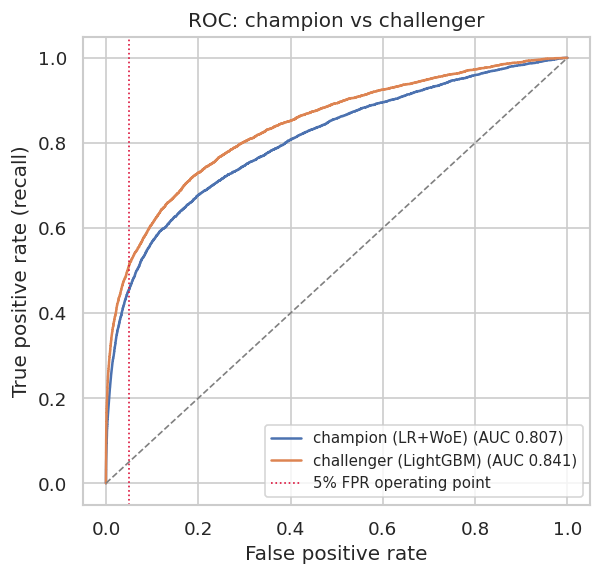

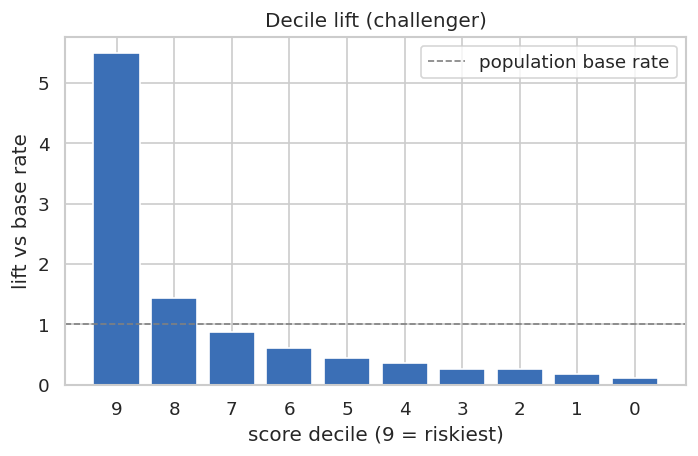

In [6]:
s_champ, s_chall = score_champion(champ, test), score_challenger(chall, test)
summary = pd.DataFrame({'champion (LR+WoE)': discrimination_summary(test[TARGET], s_champ),
                        'challenger (LightGBM)': discrimination_summary(test[TARGET], s_chall)}).T
display(summary)
plots.plot_roc(test[TARGET], {'champion (LR+WoE)': s_champ, 'challenger (LightGBM)': s_chall}, f'{OUT}/roc.png')
plots.plot_lift(lift_table(test[TARGET], s_chall), f'{OUT}/lift.png')
display(Image(f'{OUT}/roc.png')); display(Image(f'{OUT}/lift.png'))

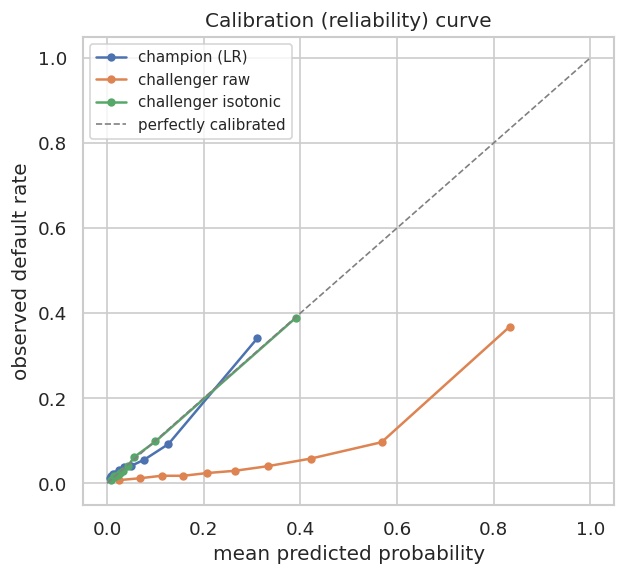

In [7]:
# challenger calibrated out-of-fold (isotonic) in build_pipeline.py
display(Image(f'{OUT}/calibration.png'))

**Insight.** Both clear the bar (champion AUC ~0.81 / KS ~0.49; challenger ~0.84 / KS ~0.53). The challenger ranks better but is more over-confident, isotonic calibration corrects its probabilities, which matters whenever a downstream expected-loss = PD x exposure calculation needs the *probability*, not just the rank.

## 6. Champion-challenger decision

Pin a business operating point (5% FPR), compare recall there, bootstrap the lift with **paired**
resampling, and apply a **pre-registered** rule (fixed before seeing the numbers).

In [8]:
stats = bootstrap_recall_diff(test[TARGET].to_numpy(), s_champ, s_chall, n=1000)
dec = decide(stats)
eco = economic_impact(test[TARGET].to_numpy(), stats)
print(f"recall  champion {stats['champ_recall']:.1%}  challenger {stats['chall_recall']:.1%}")
print(f"lift {dec['lift_pp']}pp  95% CI [{stats['ci_low']*100:.1f}, {stats['ci_high']*100:.1f}]pp")
print(f"VERDICT: {dec['verdict']}")
print(f"extra defaulters caught {eco['extra_defaulters_caught']:,}  ->  loss avoided ${eco['loss_avoided']:,}")

recall  champion 45.5%  challenger 51.1%
lift 5.63pp  95% CI [4.5, 6.8]pp
VERDICT: SHIP challenger
extra defaulters caught 283  ->  loss avoided $1,415,000


**Insight.** At an identical 5% FPR (same good customers declined) the challenger catches materially more defaulters and the CI lower bound stays positive, so the rule says **ship**. Because the FPR is held equal, the extra false-positive cost is ~zero and the net value is simply extra-bads-caught x average-loss. The 1-page version is `outputs/readout.pdf`.

## 7. Post-deployment monitoring (PSI / CSI)

Now simulate production: score six batches with the champion and watch for drift. We injected a
known escalating shift on `DebtRatio` in batches 4-6 and left `age` as a control, the monitor
must catch the former and stay quiet on the latter. **Bin edges are frozen on the baseline.**

,batch,psi,severity
0,2,0.0010,stable
1,3,0.0006,stable
2,4,0.0457,stable
3,5,0.1530,monitor
4,6,0.2899,shift


,batch2,batch3,batch4,batch5,batch6
RevolvingUtilizationOfUnsecuredLines,0.0002,0.0010,0.0016,0.0006,0.0007
DebtRatio,0.0003,0.0003,0.1275,0.3816,0.6952
MonthlyIncome,0.0000,0.0000,0.0001,0.0000,0.0000
age,0.0011,0.0008,0.0015,0.0011,0.0010
NumberOfOpenCreditLinesAndLoans,0.0004,0.0002,0.0006,0.0005,0.0002


drift detected:


,feature,batch,csi,severity,action
0,DebtRatio,batch6,0.6952,shift,retrain
1,DebtRatio,batch5,0.3816,shift,retrain
2,DebtRatio,batch4,0.1275,monitor,investigate


VERIFY injected drift: {'injected_feature': 'DebtRatio', 'injected_batches': [4, 5, 6], 'caught_injected_drift': True, 'escalating_trend': True, 'control_feature': 'age', 'control_stayed_stable': True, 'passed': True}


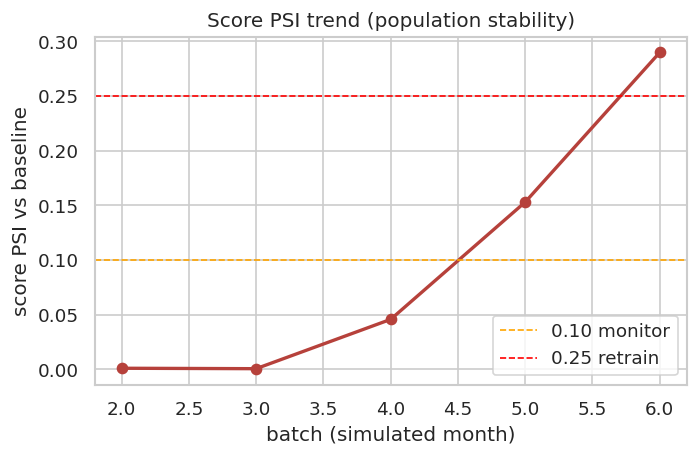

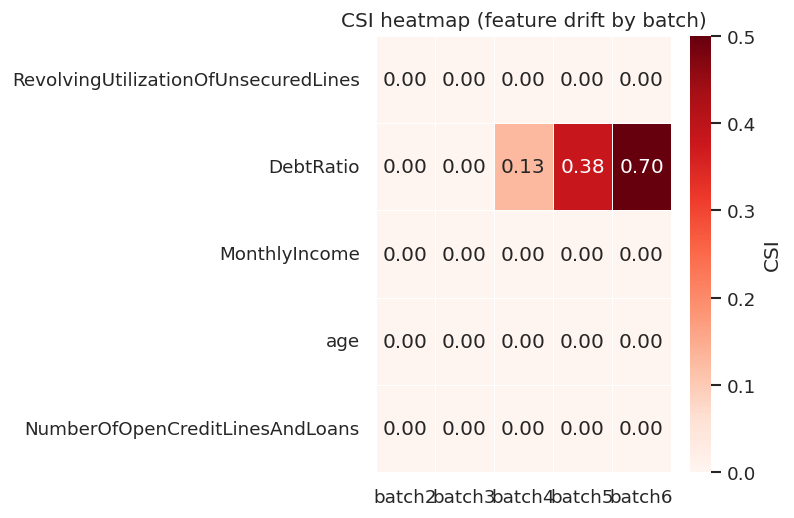

In [9]:
drifted = apply_drift(raw, drift_spec())
mon_scores = score_champion(champ, prep_apply(drifted, params))
csi_feats = ['RevolvingUtilizationOfUnsecuredLines','DebtRatio','MonthlyIncome','age','NumberOfOpenCreditLinesAndLoans']
psi_score, csi = run_monitoring(drifted.reset_index(drop=True), mon_scores, csi_feats)
display(psi_score); display(csi)
print('drift detected:'); display(drift_table(csi))
print('VERIFY injected drift:', verify_drift(csi, drift_spec()))
plots.plot_psi_trend(psi_score, f'{OUT}/psi_trend.png')
plots.plot_csi_heatmap(csi, f'{OUT}/csi_heatmap.png')
display(Image(f'{OUT}/psi_trend.png')); display(Image(f'{OUT}/csi_heatmap.png'))

**Insight.** CSI on `DebtRatio` escalates 0.13 -> 0.38 -> 0.70 across batches 4-6 (into the >0.25 retrain band) while the `age` control stays ~0.00, the monitor caught exactly the drift we injected and nothing else, so the logic is trustworthy. Score PSI rises more slowly because `DebtRatio` is one of several features: PSI is an early *alarm*, CSI the *diagnosis*, and a high PSI is a warning to investigate, not by itself proof the model has failed.

## 8. Limitations & future work

- Time windows are **simulated** (the dataset has no timestamp); drift is injected to test the monitor against ground truth. Production needs a real vintage.
- Data is a synthetic GMSC-schema generator so the project runs without Kaggle credentials; dropping the real `cs-training.csv` into `data/` swaps it in unchanged.
- Fairness/bias (PSI by gender/age) is out of scope here, a clear next step.
- WoE is refit per CV fold for honest scoring; a production scorecard would also re-derive bins on each retrain.